# LSTM Prediction

In [1]:
# ============================================================================
# BLOCK 1: IMPORTS AND SETUP
# ============================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Add your custom libraries path
MY_LIB_PATH = r"/home/seba/Documentos/Data Science Projects/seba-libs"
sys.path.append(MY_LIB_PATH)

from wave_generator import WaveLibrary
from model_preparation import ModelPreparation

print("✓ All libraries imported successfully")

2025-11-17 12:18:43.214075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 12:18:43.239267: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 12:18:44.000875: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✓ All libraries imported successfully


In [2]:
# ============================================================================
# BLOCK 2: KEY CONFIGURATION VARIABLES
# ============================================================================
"""
UNDERSTANDING THE CONFIGURATION VARIABLES:

1. SEQUENCE_LENGTH (Window Size):
   - How many past time steps the LSTM looks at to make a prediction
   - TOO SMALL: Model can't see enough pattern (e.g., 10 for a wave with period 50)
   - TOO LARGE: Model gets confused with too much irrelevant data
   - RULE OF THUMB: Should cover 1-2 complete cycles of your pattern
   - For a wave with frequency 2.0 Hz over time 0-1: period = 1/2.0 = 0.5 seconds
     With 1000 samples, one period = 500 samples, so use 100-200 for sequence length

2. N_SAMPLES:
   - Total data points generated
   - MORE SAMPLES = More training data, better learning (but slower)
   - FEWER SAMPLES = Faster training but might not capture pattern well
   - RECOMMENDATION: At least 1000-5000 for simple patterns

3. NOISE_LEVEL:
   - Random noise added to signal (0.0 = no noise, 0.5 = very noisy)
   - HIGH NOISE: Model has harder time learning pattern
   - Start with LOW noise (0.01-0.05) to ensure model can learn the pattern

4. TEST_SIZE:
   - Proportion of data for testing (0.2 = 20%)
   - LARGER: More data to evaluate, but less to train
   - SMALLER: More training data, but less evaluation data
   - STANDARD: 0.2 (20%) is typical

5. LSTM_UNITS (Layer Sizes):
   - Number of neurons in each LSTM layer
   - MORE UNITS: Can learn complex patterns but risk overfitting
   - FEWER UNITS: Faster training but might not capture complexity
   - RULE: Start with 50-100, reduce if overfitting

6. DROPOUT_RATE:
   - Randomly turns off neurons during training to prevent overfitting
   - 0.0 = no dropout, 0.5 = drop 50% of neurons
   - TOO HIGH: Model can't learn well (underfitting)
   - TOO LOW: Model memorizes training data (overfitting)
   - RECOMMENDATION: 0.1-0.2 for simple patterns

7. EPOCHS:
   - Number of times model sees all training data
   - MORE EPOCHS: Better learning but risk overfitting
   - EarlyStopping callback prevents overfitting by stopping when validation stops improving

8. BATCH_SIZE:
   - Number of samples processed before updating model weights
   - SMALLER: More frequent updates, noisier learning (might be better)
   - LARGER: Faster training, smoother learning
   - RECOMMENDATION: 16-32 for small datasets
"""

# IMPROVED CONFIGURATION FOR YOUR WAVE
SEQUENCE_LENGTH = 100       # ↑ Increased to capture more pattern (was 30)
                            # With freq 2.0, period ≈ 500 samples, so 100 sees ~20% of cycle

PREDICTION_POINTS = 200     # Number of points to predict/visualize

N_SAMPLES = 2000           # ↑ More data for better learning (was 1000)

NOISE_LEVEL = 0.1         # ↓ Even less noise for cleaner learning (was 0.05)

TEST_SIZE = 0.25           # 25% for testing (was 0.3)

# Model hyperparameters - MORE CAPACITY
LSTM_UNITS_1 = 100         # ↑ More neurons to learn pattern (was 50)
LSTM_UNITS_2 = 50          # ↑ More neurons (was 25)
DROPOUT_RATE = 0.1         # Keep low for this simple pattern

EPOCHS = 100               # ↑ More epochs (was 80)
BATCH_SIZE = 16            # Keep small for better learning

# Learning rate
LEARNING_RATE = 0.001      # Standard learning rate for Adam optimizer

print("="*70)
print("IMPROVED CONFIGURATION")
print("="*70)
print(f"Data Generation:")
print(f"  - Total Samples:    {N_SAMPLES:>6} (more data for learning)")
print(f"  - Noise Level:      {NOISE_LEVEL:>6.3f} (lower for cleaner signal)")
print(f"  - Test Size:        {TEST_SIZE:>6.1%} (balanced split)")
print()
print(f"Model Architecture:")
print(f"  - Sequence Length:  {SEQUENCE_LENGTH:>6} samples (looks further back)")
print(f"  - LSTM Layer 1:     {LSTM_UNITS_1:>6} units (more capacity)")
print(f"  - LSTM Layer 2:     {LSTM_UNITS_2:>6} units")
print(f"  - Dropout Rate:     {DROPOUT_RATE:>6.1%}")
print()
print(f"Training:")
print(f"  - Max Epochs:       {EPOCHS:>6} (early stopping active)")
print(f"  - Batch Size:       {BATCH_SIZE:>6}")
print(f"  - Learning Rate:    {LEARNING_RATE:>6.4f}")
print(f"  - Visualization:    {PREDICTION_POINTS:>6} predictions")
print("="*70)



IMPROVED CONFIGURATION
Data Generation:
  - Total Samples:      2000 (more data for learning)
  - Noise Level:       0.100 (lower for cleaner signal)
  - Test Size:         25.0% (balanced split)

Model Architecture:
  - Sequence Length:     100 samples (looks further back)
  - LSTM Layer 1:        100 units (more capacity)
  - LSTM Layer 2:         50 units
  - Dropout Rate:      10.0%

Training:
  - Max Epochs:          100 (early stopping active)
  - Batch Size:           16
  - Learning Rate:    0.0010
  - Visualization:       200 predictions


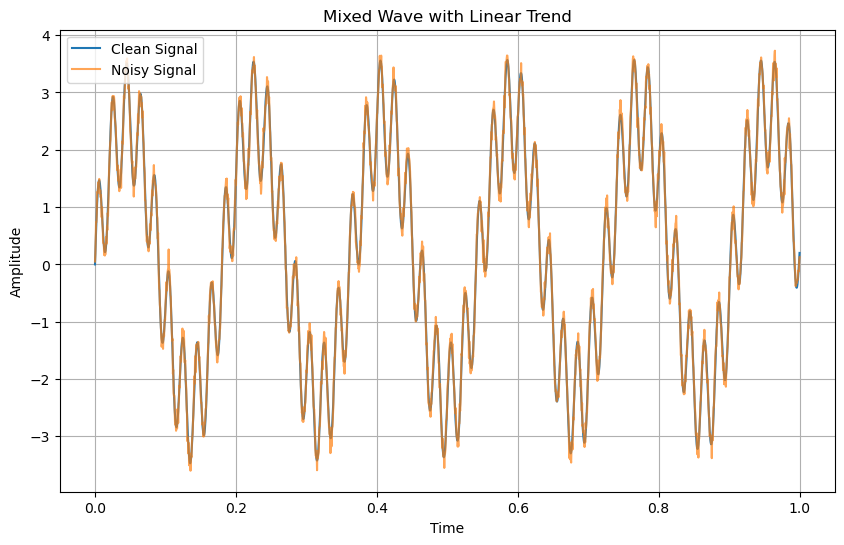

✓ Generated SIMPLE wave data with shape: (2000, 11)
  Pattern: 2 sine waves (frequencies: 2.0 Hz, 0.5 Hz) + gentle trend
  Columns: ['time', 'component_0_type', 'component_0_frequency', 'component_0_amplitude', 'component_0_phase', 'component_1_type', 'component_1_frequency', 'component_1_amplitude', 'component_1_phase', 'signal', 'signal_with_noise']


In [3]:
# ============================================================================
# BLOCK 3: GENERATE SYNTHETIC WAVE DATA
# ============================================================================
# Initialize wave generator
wave_lib = WaveLibrary(n_samples=N_SAMPLES, seed=42, noise_level=NOISE_LEVEL)

# Generate a SIMPLE sine wave with gentle trend
# This is much easier for the LSTM to learn and predict
components = [
    {'type': 'sine', 'frequency': 50.0, 'amplitude': 1.0, 'phase': 0.0},  # Main pattern
    {'type': 'sine', 'frequency': 5.5, 'amplitude': 2.5, 'phase': 0.0}   # Slower variation
]

# Generate the wave with a gentle linear trend
wave_df = wave_lib.generate_mixed_wave_with_trend(
    components=components, 
    trend_slope=0.2,  # Gentle upward trend
    plot=True
)

print(f"✓ Generated SIMPLE wave data with shape: {wave_df.shape}")
print(f"  Pattern: 2 sine waves (frequencies: 2.0 Hz, 0.5 Hz) + gentle trend")
print(f"  Columns: {wave_df.columns.tolist()}")

In [4]:
# ============================================================================
# BLOCK 4: PREPARE DATA FOR LSTM
# ============================================================================
"""
CRITICAL INSIGHT: Time series forecasting with LSTM

The model needs to learn from PAST VALUES of the signal, not just time!
- WRONG: Use 'time' to predict next value → Time alone has no pattern
- RIGHT: Use past 'signal values' to predict next value → Signal contains pattern

Think of it like: "Given the last 100 signal readings, what's the next reading?"
NOT: "Given time = 0.543, what's the signal?" (impossible without history!)
"""

# Use the SIGNAL VALUES as features to predict the NEXT signal value
# This is the standard approach for univariate time series forecasting
unified_df = pd.DataFrame({
    'signal': wave_df['signal_with_noise']  # Use signal history to predict next signal
})

# We'll treat this as: X = past signal values, y = next signal value
# The target is the same column - we're doing autoregressive forecasting
unified_df['target'] = unified_df['signal']

print(f"✓ Unified dataframe shape: {unified_df.shape}")
print(f"  Column: signal (past values used to predict future)")
print(f"  First few rows:")
print(unified_df.head())
print("\n  This setup means: Given last {SEQUENCE_LENGTH} signal values → Predict next value")


# ============================================================================
# BLOCK 5: TEMPORAL TRAIN-TEST SPLIT
# ============================================================================
# Use temporal split (no shuffling) to preserve time series order
X_train, X_test, y_train, y_test = ModelPreparation.temporal_train_test_split(
    unified_df=unified_df,
    target_col='target',
    test_size=TEST_SIZE
)

print("\n✓ Data split completed")


# ============================================================================
# BLOCK 6: CREATE WINDOWED SEQUENCES
# ============================================================================
# Create sequences for LSTM input
X_train_seq, X_test_seq, y_train_seq, y_test_seq = ModelPreparation.create_window_sequences(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    seq_length=SEQUENCE_LENGTH
)

print("\n✓ Sequences created successfully")
print(f"  X_train_seq shape: {X_train_seq.shape} -> (samples, sequence_length, features)")
print(f"  y_train_seq shape: {y_train_seq.shape} -> (samples,)")



✓ Unified dataframe shape: (2000, 2)
  Column: signal (past values used to predict future)
  First few rows:
     signal    target
0  0.049671  0.049671
1  0.186002  0.186002
2  0.460555  0.460555
3  0.736401  0.736401
4  0.737761  0.737761

  This setup means: Given last {SEQUENCE_LENGTH} signal values → Predict next value
Shape of X_train: (1500, 1)
Shape of X_test: (500, 1)
Shape of y_train: (1500,)
Shape of y_test: (500,)

✓ Data split completed
Shape of X_train_seq: (1400, 100, 1)
Shape of X_test_seq: (400, 100, 1)
Shape of y_train_seq: (1400,)
Shape of y_test_seq: (400,)

✓ Sequences created successfully
  X_train_seq shape: (1400, 100, 1) -> (samples, sequence_length, features)
  y_train_seq shape: (1400,) -> (samples,)



✓ Model built successfully
  - Input shape: (batch, 100, 1)
  - Total parameters: 71,051


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training...
Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.6468 - mae: 0.6083 - val_loss: 0.0664 - val_mae: 0.2065 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0607 - mae: 0.1958 - val_loss: 0.0298 - val_mae: 0.1398 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0441 - mae: 0.1632 - val_loss: 0.0268 - val_mae: 0.1318 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0463 - mae: 0.1682 - val_loss: 0.0280 - val_mae: 0.1356 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0391 - mae: 0.1512 - val_loss: 0.0224 - val_mae: 0.1234 - learning_rate: 0.0010
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0393 - mae: 0.1559 - val_loss: 0.0198 - val_mae: 0.1149 - learning_rate: 0.0010
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0374 - mae: 0.1508 - val_loss: 0.0250 - val_mae: 0.1289 - lear

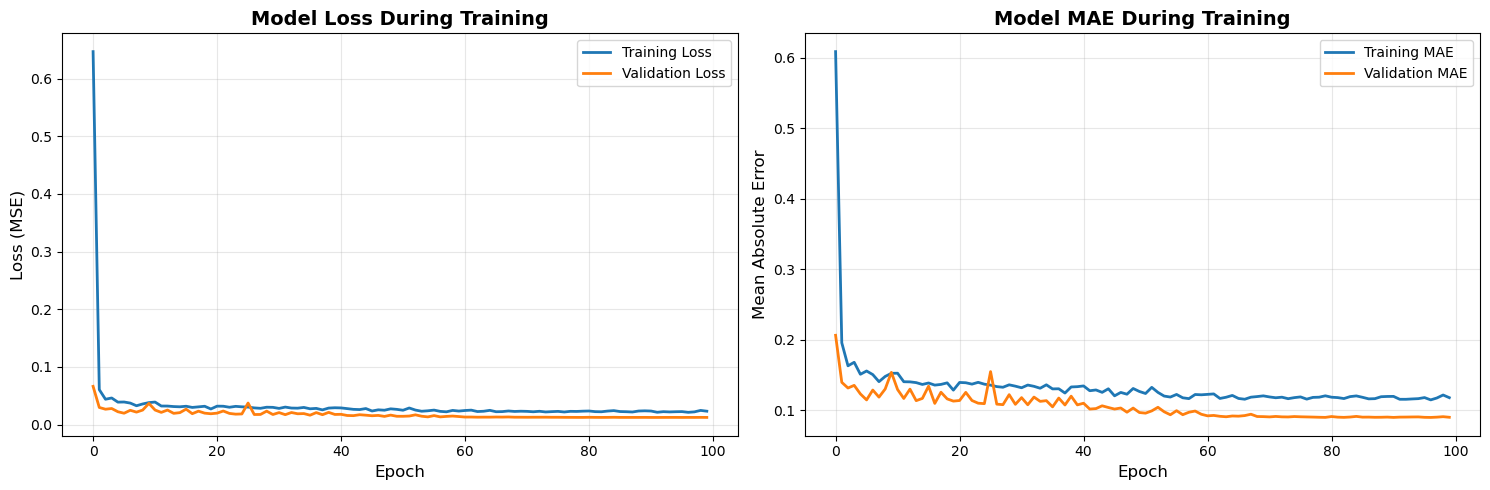

In [5]:
# ============================================================================
# BLOCK 7: BUILD LSTM MODEL
# ============================================================================
model = Sequential([
    # First LSTM layer with return sequences
    LSTM(LSTM_UNITS_1, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    Dropout(DROPOUT_RATE),
    
    # Second LSTM layer
    LSTM(LSTM_UNITS_2, return_sequences=False),
    Dropout(DROPOUT_RATE),
    
    # Dense output layer
    Dense(1)
])

# Compile the model with custom learning rate
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

print("\n✓ Model built successfully")
print(f"  - Input shape: (batch, {SEQUENCE_LENGTH}, {X_train_seq.shape[2]})")
print(f"  - Total parameters: {model.count_params():,}")
model.summary()


# ============================================================================
# BLOCK 8: TRAIN THE MODEL
# ============================================================================
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,              # Increased patience
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when plateauing
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # Reduce LR by half
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train the model
print("\n🚀 Starting training...")
print("="*70)
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n" + "="*70)
print("✓ Training completed!")
print(f"  Final training loss: {history.history['loss'][-1]:.6f}")
print(f"  Final validation loss: {history.history['val_loss'][-1]:.6f}")
print("="*70)

# ============================================================================
# BLOCK 9: EVALUATE THE MODEL
# ============================================================================
# Make predictions
y_pred = model.predict(X_test_seq)
y_pred = y_pred.flatten()  # Flatten to 1D array

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_seq, y_pred)
mae = mean_absolute_error(y_test_seq, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_seq, y_pred)

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"Root Mean Squared Error:   {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R² Score:                  {r2:.6f}")
print("="*60)


# ============================================================================
# BLOCK 10: PLOT TRAINING HISTORY
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error', fontsize=12)
axes[1].set_title('Model MAE During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
wave_df

,time,component_0_type,component_0_frequency,component_0_amplitude,component_0_phase,component_1_type,component_1_frequency,component_1_amplitude,component_1_phase,signal,signal_with_noise
0,0.000000,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,0.000000,0.049671
1,0.000500,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,0.199828,0.186002
2,0.001001,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,0.395786,0.460555
3,0.001501,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,0.584098,0.736401
4,0.002001,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,0.761176,0.737761
...,...,...,...,...,...,...,...,...,...,...,...
1995,0.997999,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,-0.215703,-0.108688
1996,0.998499,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,-0.124903,-0.127555
1997,0.998999,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,-0.022947,-0.111134
1998,0.999500,sine,50.0,1.0,0.0,sine,5.5,2.5,0.0,0.086604,0.070298


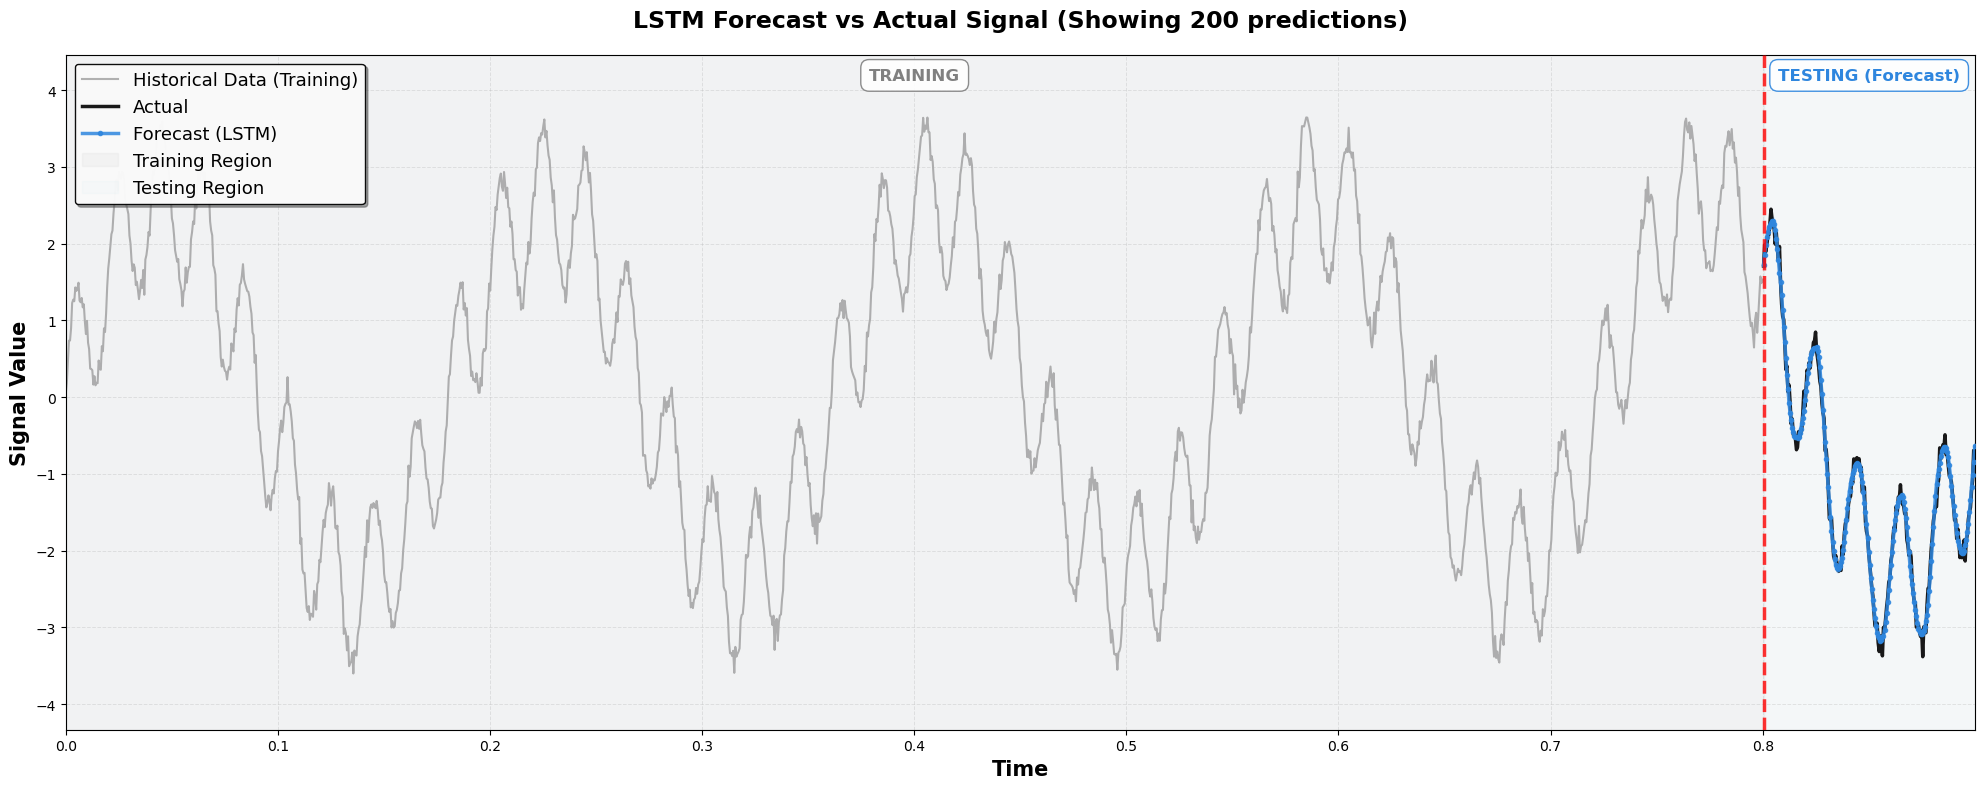

✓ Visualization shows:
  - Gray line: Historical training data
  - Black line: Actual test values
  - Blue line: LSTM predictions
  - Red line: Point where forecasting begins


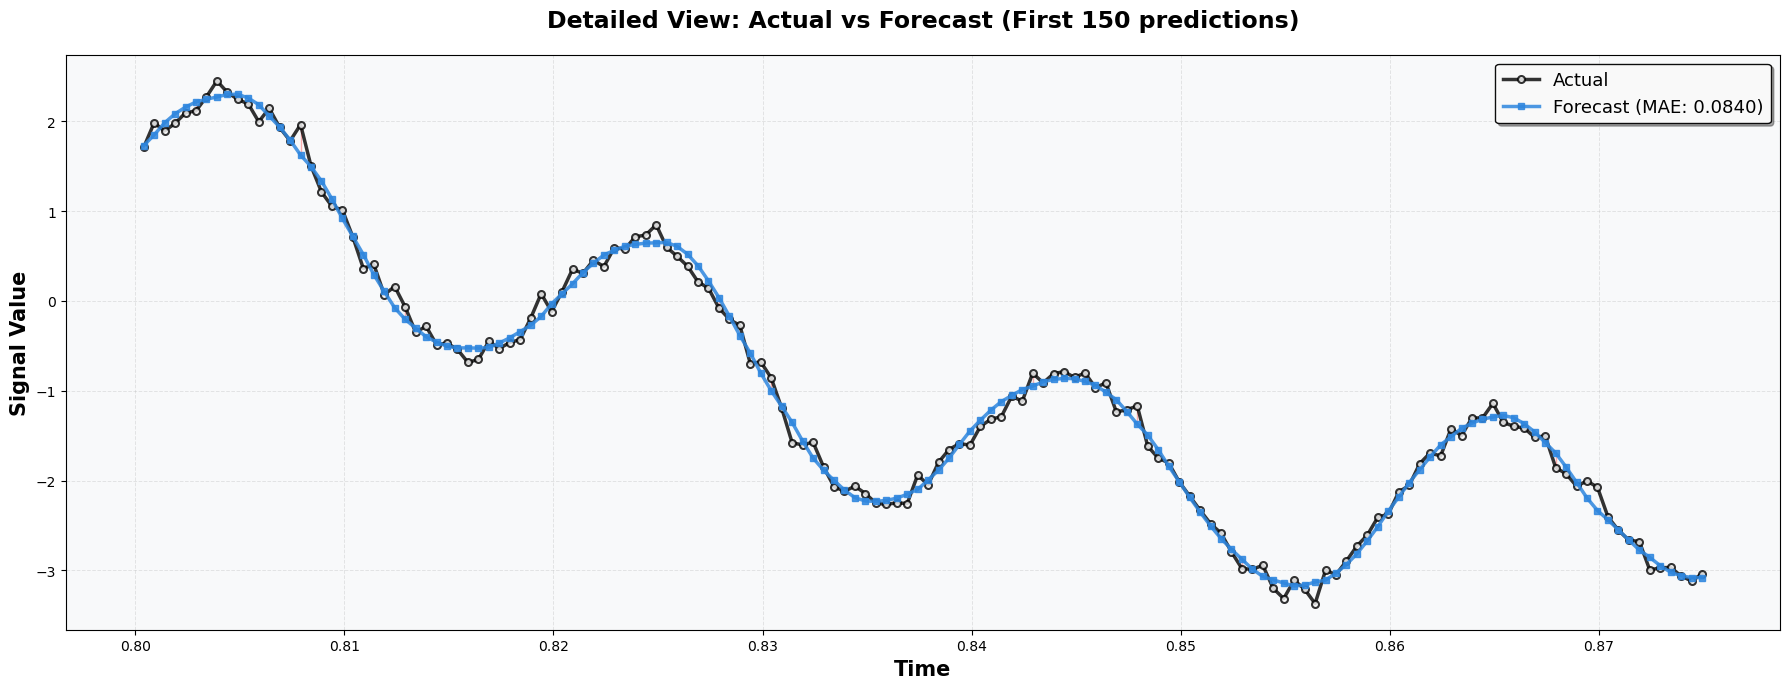

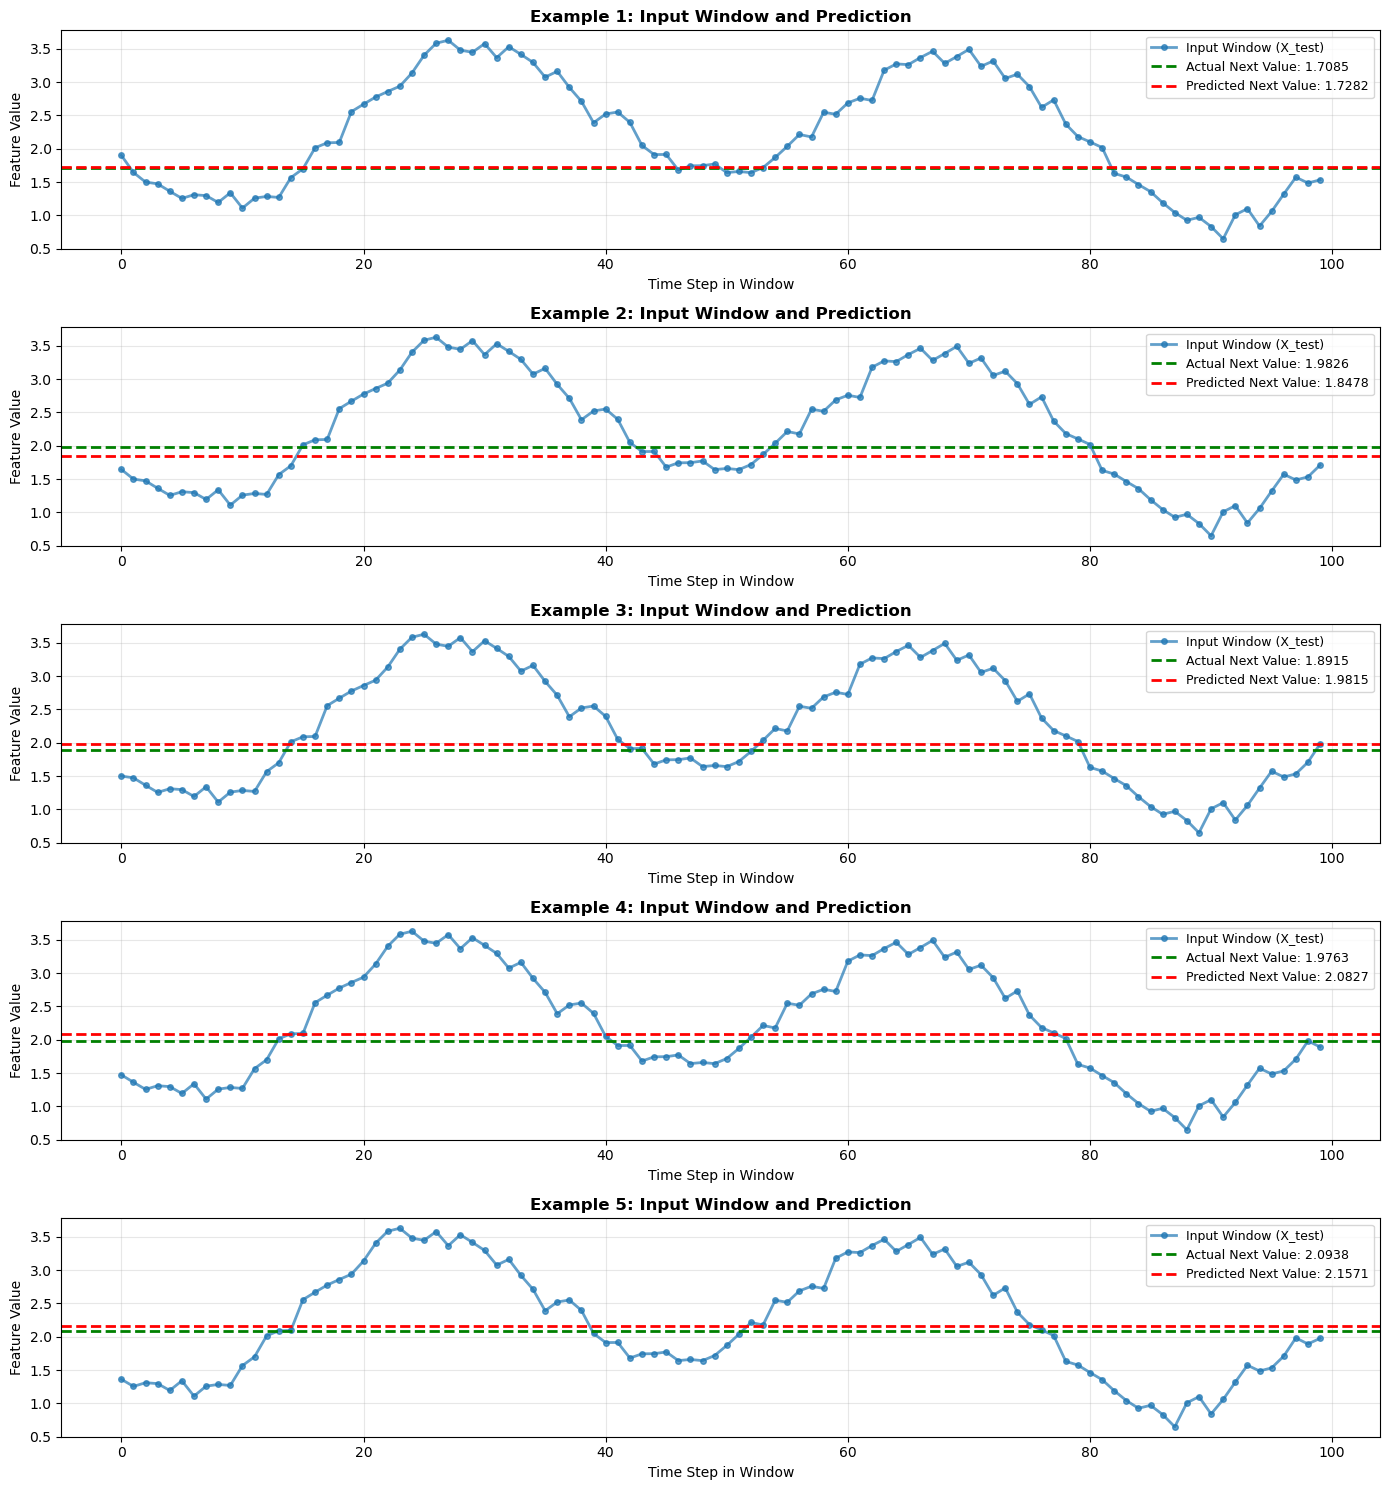


✓ All visualizations completed!


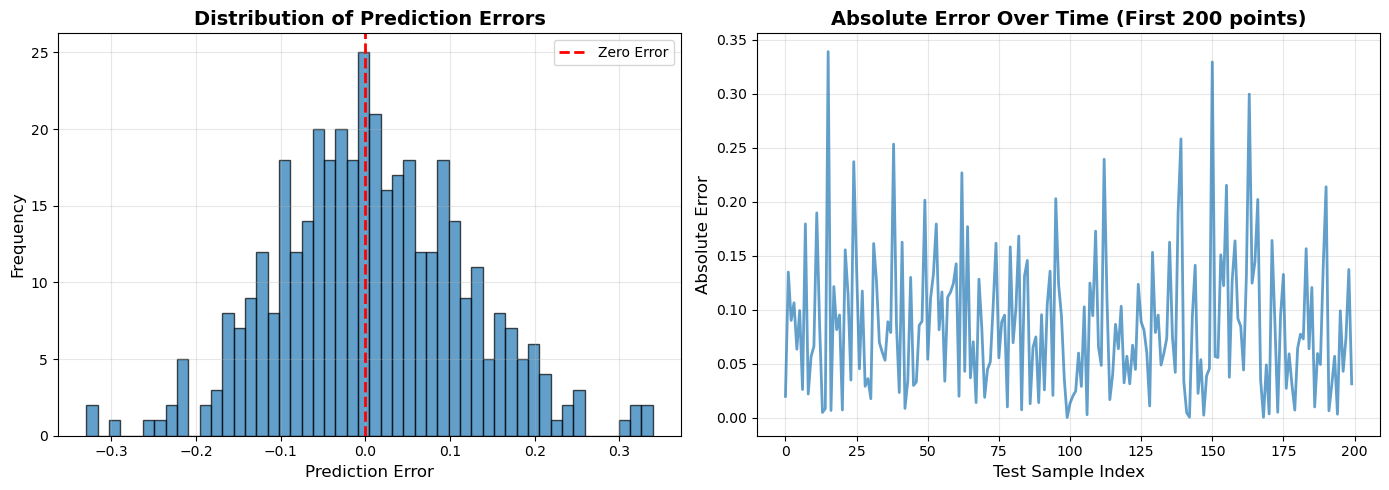


WORKFLOW COMPLETED SUCCESSFULLY! 🎉

Next steps:
1. Adjust SEQUENCE_LENGTH to see how it affects predictions
2. Modify the wave components to test different patterns
3. Replace wave_df with your real time series data
4. Experiment with LSTM architecture (units, layers, dropout)


In [6]:

# ============================================================================
# BLOCK 11: VISUALIZE PREDICTIONS OVER ORIGINAL TIME SERIES
# ============================================================================
# Reconstruct the full time series to show where predictions occur

# Get the original time values from the test set
# Remember: we lost SEQUENCE_LENGTH points when creating sequences
train_size = len(X_train)
test_start_idx = train_size + SEQUENCE_LENGTH  # Where test predictions start

# Get original time and signal from wave_df
original_time = wave_df['time'].values
original_signal = wave_df['signal_with_noise'].values

# Calculate time indices for predictions
pred_start_idx = test_start_idx
pred_end_idx = pred_start_idx + len(y_pred)

# Time values for predictions
time_pred = original_time[pred_start_idx:pred_end_idx]

# Limit visualization points if needed
n_points = min(PREDICTION_POINTS, len(y_pred))

# Create the main plot with better styling
fig, ax = plt.subplots(figsize=(20, 8))

# Plot TRAINING portion of original signal (gray)
train_end_time = original_time[pred_start_idx]
train_mask = original_time < train_end_time
ax.plot(original_time[train_mask], original_signal[train_mask], 
        'gray', linewidth=1.5, label='Historical Data (Training)', alpha=0.6, zorder=1)

# Plot TEST portion of original signal (black/actual)
test_mask = (original_time >= train_end_time) & (original_time < time_pred[n_points-1])
ax.plot(original_time[test_mask], original_signal[test_mask], 
        'k-', linewidth=2.5, label='Actual', alpha=0.9, zorder=2)

# Plot predictions (blue with markers for clarity)
ax.plot(time_pred[:n_points], y_pred[:n_points], 
        color='#2E86DE', linewidth=2.5, marker='o', markersize=3,
        label='Forecast (LSTM)', alpha=0.85, zorder=3)

# Add subtle shaded area for forecast
ax.fill_between(time_pred[:n_points], 
                y_pred[:n_points] - 0.05,  # Small confidence band
                y_pred[:n_points] + 0.05, 
                alpha=0.2, color='#2E86DE', zorder=1)

# Mark the transition point clearly
ax.axvline(x=train_end_time, color='red', linestyle='--', 
           linewidth=2.5, alpha=0.8, zorder=4)

# Add shaded regions to clearly show Training vs Testing
ax.axvspan(original_time[0], train_end_time, alpha=0.05, color='gray', zorder=0, label='Training Region')
ax.axvspan(train_end_time, time_pred[n_points-1], alpha=0.05, color='lightblue', zorder=0, label='Testing Region')

# Add text annotations at the top of the plot
y_top = original_signal.max() + (original_signal.max() - original_signal.min()) * 0.05
mid_train_time = (original_time[0] + train_end_time) / 2
mid_test_time = (train_end_time + time_pred[n_points-1]) / 2

ax.text(mid_train_time, y_top, 'TRAINING', 
        fontsize=12, color='gray', fontweight='bold',
        horizontalalignment='center', verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

ax.text(mid_test_time, y_top, 'TESTING (Forecast)', 
        fontsize=12, color='#2E86DE', fontweight='bold',
        horizontalalignment='center', verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#2E86DE', alpha=0.9))

# Improved styling
ax.set_xlabel('Time', fontsize=15, fontweight='bold')
ax.set_ylabel('Signal Value', fontsize=15, fontweight='bold')
ax.set_title(f'LSTM Forecast vs Actual Signal (Showing {n_points} predictions)', 
             fontsize=17, fontweight='bold', pad=20)

# Better legend
ax.legend(fontsize=13, loc='upper left', framealpha=0.95, 
          edgecolor='black', fancybox=True, shadow=True)

# Enhanced grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_facecolor('#f8f9fa')

# Set better limits
ax.set_xlim(original_time[0], time_pred[n_points-1])
y_margin = (original_signal.max() - original_signal.min()) * 0.1
ax.set_ylim(original_signal.min() - y_margin, original_signal.max() + y_margin)

plt.tight_layout()
plt.show()

print(f"✓ Visualization shows:")
print(f"  - Gray line: Historical training data")
print(f"  - Black line: Actual test values")
print(f"  - Blue line: LSTM predictions")
print(f"  - Red line: Point where forecasting begins")


# ============================================================================
# BLOCK 12: DETAILED COMPARISON - ACTUAL vs FORECAST (ZOOMED)
# ============================================================================
# Show a closer view of the prediction region

fig, ax = plt.subplots(figsize=(18, 7))

# Focus only on the test/prediction region
display_points = min(150, n_points)  # Show up to 150 points for clarity

# Plot actual values
ax.plot(time_pred[:display_points], y_test_seq[:display_points], 
        'ko-', linewidth=2.5, markersize=5, label='Actual', 
        alpha=0.8, zorder=2, markerfacecolor='white', markeredgewidth=1.5)

# Plot predictions
ax.plot(time_pred[:display_points], y_pred[:display_points], 
        color='#2E86DE', linewidth=2.5, marker='s', markersize=4,
        label='Forecast', alpha=0.85, zorder=3, markerfacecolor='#2E86DE')

# Add error bars showing prediction accuracy
errors = np.abs(y_test_seq[:display_points] - y_pred[:display_points])
for i in range(0, display_points, 5):  # Show every 5th error bar to avoid clutter
    ax.plot([time_pred[i], time_pred[i]], 
            [y_test_seq[i], y_pred[i]], 
            'r-', alpha=0.3, linewidth=1, zorder=1)

# Styling
ax.set_xlabel('Time', fontsize=15, fontweight='bold')
ax.set_ylabel('Signal Value', fontsize=15, fontweight='bold')
ax.set_title(f'Detailed View: Actual vs Forecast (First {display_points} predictions)', 
             fontsize=17, fontweight='bold', pad=20)

# Legend with performance metric
mae_display = mean_absolute_error(y_test_seq[:display_points], y_pred[:display_points])
legend_labels = [f'Actual', f'Forecast (MAE: {mae_display:.4f})']
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, fontsize=13, loc='best', 
          framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()


# ============================================================================
# BLOCK 13: VISUALIZE INPUT WINDOWS (X_test)
# ============================================================================
# Show a few example input sequences and their predictions
n_examples = 5  # Number of windows to show

fig, axes = plt.subplots(n_examples, 1, figsize=(14, 3*n_examples))

for i in range(n_examples):
    if i >= len(X_test_seq):
        break
    
    # Get the input sequence (window)
    window = X_test_seq[i]  # Shape: (SEQUENCE_LENGTH, n_features)
    
    # Since we have 1 feature (time), extract it
    window_values = window[:, 0]  # Get the time feature values
    
    # Get actual and predicted values
    actual = y_test_seq[i]
    predicted = y_pred[i]
    
    # Plot the window
    axes[i].plot(range(SEQUENCE_LENGTH), window_values, 'o-', 
                linewidth=2, markersize=4, label='Input Window (X_test)', alpha=0.7)
    
    # Mark the prediction point
    axes[i].axhline(y=actual, color='green', linestyle='--', 
                   linewidth=2, label=f'Actual Next Value: {actual:.4f}')
    axes[i].axhline(y=predicted, color='red', linestyle='--', 
                   linewidth=2, label=f'Predicted Next Value: {predicted:.4f}')
    
    axes[i].set_xlabel('Time Step in Window', fontsize=10)
    axes[i].set_ylabel('Feature Value', fontsize=10)
    axes[i].set_title(f'Example {i+1}: Input Window and Prediction', 
                     fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9, loc='best')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ All visualizations completed!")


# ============================================================================
# BLOCK 14: ERROR ANALYSIS
# ============================================================================
# Calculate prediction errors
errors = y_test_seq - y_pred
abs_errors = np.abs(errors)

plt.figure(figsize=(14, 5))

# Error distribution
plt.subplot(1, 2, 1)
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.legend()
plt.grid(True, alpha=0.3)

# Error over time
plt.subplot(1, 2, 2)
plt.plot(abs_errors[:n_points], linewidth=2, alpha=0.7)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)
plt.title(f'Absolute Error Over Time (First {n_points} points)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("WORKFLOW COMPLETED SUCCESSFULLY! 🎉")
print("="*60)
print("\nNext steps:")
print("1. Adjust SEQUENCE_LENGTH to see how it affects predictions")
print("2. Modify the wave components to test different patterns")
print("3. Replace wave_df with your real time series data")
print("4. Experiment with LSTM architecture (units, layers, dropout)")
print("="*60)